# RoBERTa Multi-Class Diagnosis Models

Trains **two** RoBERTa classifiers on `generated_augmented_nonsuicidewatch_filtered_data`:

1. **3-class severity model** — predicts `threeclass_label`.
2. **Subreddit model** — predicts `multiclass_label` (after dropping ultra-rare classes).

Each model gets its own 80/10/10 stratified split, class-weighted loss, and checkpoint.

**Data Version:** v5 control class is filtered to include only emotional confessions suicide watch class fully restored


## Section 1: Imports

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


## Section 2: Load `generated_augmented_nonsuicidewatch_filtered_data` and minimal preprocessing

In [2]:
generated_augmented_nonsuicidewatch_filtered_data=pd.read_csv("generated_augmented_nonsuicidewatch_filtered_data.csv")

In [3]:
# generated_augmented_nonsuicidewatch_filtered_data is expected to already exist in the kernel with columns:
#   other_posts, multiclass_label, threeclass_label
# If you need to load it from disk, uncomment the line below:
# generated_augmented_nonsuicidewatch_filtered_data = pd.read_csv('generated_augmented_nonsuicidewatch_filtered_data.csv')

data = generated_augmented_nonsuicidewatch_filtered_data.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset shape:', data.shape)
print('\nColumns:', data.columns.tolist())
print('\nthreeclass_label distribution:')
print(data['threeclass_label'].value_counts(dropna=False))
print('\nmulticlass_label distribution:')
print(data['multiclass_label'].value_counts(dropna=False))

Dataset shape: (80301, 31)

Columns: ['author', 'subreddit', 'report_post', 'other_posts', 'is_self_report', 'is_control', 'self_report_sentence', 'selfdiag_score', 'selfdiag_matches', 'severe_flag', 'label', 'multiclass_label', 'threeclass_label', 'clean_text', 'emotion_matches', 'emotion_score', 'emotion_hits', 'emotion_triggered_patterns', 'has_risk_leakage', 'risk_hits', 'word_count', 'control_emotion_decision', 'source', 'matches', 'score', 'decision', 'text', 'fiveclass_label', 'risk', 'is_emotional_control', 'emotion_type']

threeclass_label distribution:
threeclass_label
at_risk     57965
suicidal    14713
normal       7550
control        73
Name: count, dtype: int64

multiclass_label distribution:
multiclass_label
suicidewatch     14713
adhd             12551
anxiety          10101
control           9342
depression        9123
mentalhealth      8092
socialanxiety     2988
bpd               2954
ptsd              2679
autism            1648
schizophrenia     1347
healthanxiety 

In [4]:
def minimal_preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['other_posts'] = data['other_posts'].apply(minimal_preprocess)
data = data[data['other_posts'].str.len() > 0].reset_index(drop=True)
print(f'After cleaning empty text: {len(data)} rows')

After cleaning empty text: 79937 rows


## Section 3: Shared building blocks (Dataset, train, eval)

In [5]:
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc='Training'):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        outputs = model(**batch)
        loss = loss_fn(outputs.logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, eval_loader, device, loss_fn):
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc='Evaluating'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
    return total_loss / len(eval_loader), accuracy_score(true_labels, predictions), predictions, true_labels


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

MODEL_NAME = 'roberta-base'
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

Using device: cuda


## Section 4: End-to-end training function

Given a dataframe + label column, this prepares splits, encodes labels, computes class weights, trains a RoBERTa model, and reports macro / weighted P/R/F1 plus a confusion matrix. We call it twice — once per label column.

In [7]:
def run_experiment(df, label_col, model_save_path, min_samples_per_class=50):
    print('=' * 70)
    print(f'EXPERIMENT: {label_col}  ->  {model_save_path}')
    print('=' * 70)

    # 1. Drop NaN labels / empty text
    work = df.dropna(subset=[label_col, 'other_posts']).copy()

    # 2. Drop ultra-rare classes
    counts = work[label_col].value_counts()
    keep_classes = counts[counts >= min_samples_per_class].index.tolist()
    dropped = counts[counts < min_samples_per_class]
    if len(dropped) > 0:
        print(f'Dropping {len(dropped)} classes with < {min_samples_per_class} samples:')
        for cls, n in dropped.items():
            print(f'  - {cls}: {n}')
    work = work[work[label_col].isin(keep_classes)].reset_index(drop=True)

    # 3. Encode string labels -> integers
    le = LabelEncoder()
    work['_y'] = le.fit_transform(work[label_col].astype(str))
    class_names = list(le.classes_)
    num_labels = len(class_names)
    print(f'\nFinal: {len(work)} rows, {num_labels} classes')
    print('Class distribution:')
    for i, name in enumerate(class_names):
        print(f'  {i:2d} {name:<25} {(work["_y"] == i).sum()}')

    # 4. 80/10/10 stratified split
    train_df, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    print(f'\nSplit sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

    # 5. Tokenize
    def tok(texts):
        return tokenizer(texts.tolist(), max_length=MAX_LENGTH, padding='max_length',
                         truncation=True, return_tensors='pt')

    print('\nTokenizing...')
    train_enc = tok(train_df['other_posts'])
    val_enc = tok(val_df['other_posts'])
    test_enc = tok(test_df['other_posts'])

    train_ds = TextClassificationDataset(train_enc, train_df['_y'].values)
    val_ds = TextClassificationDataset(val_enc, val_df['_y'].values)
    test_ds = TextClassificationDataset(test_enc, test_df['_y'].values)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # 6. Model + class-weighted loss
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    cw = compute_class_weight('balanced', classes=np.arange(num_labels), y=train_df['_y'].values)
    class_weights = torch.tensor(cw, dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    print(f'\nClass weights computed (min={cw.min():.3f}, max={cw.max():.3f})')

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, total_iters=total_steps)

    # 7. Training loop — select on macro-F1
    best_val_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f'\n--- Epoch {epoch + 1}/{NUM_EPOCHS} ---')
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn)
        print(f'Train loss: {train_loss:.4f}')
        val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, device, loss_fn)
        val_macro_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
        print(f'Val loss: {val_loss:.4f}  acc: {val_acc:.4f}  macro-F1: {val_macro_f1:.4f}')
        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            torch.save(model.state_dict(), model_save_path)
            print(f'  -> saved best model to {model_save_path}')

    # 8. Final test eval with best checkpoint
    model.load_state_dict(torch.load(model_save_path))
    test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, device, loss_fn)
    print('\n' + '=' * 70)
    print(f'TEST RESULTS — {label_col}')
    print('=' * 70)
    print(f'Loss:        {test_loss:.4f}')
    print(f'Accuracy:    {test_acc:.4f}')
    print(f'Macro    P/R/F1: '
          f'{precision_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="macro", zero_division=0):.4f}')
    print(f'Weighted P/R/F1: '
          f'{precision_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="weighted", zero_division=0):.4f}')
    print('\nClassification report:')
    print(classification_report(test_true, test_preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    cm = confusion_matrix(test_true, test_preds, labels=list(range(num_labels)))
    print(cm)

    return {
        'model': model,
        'label_encoder': le,
        'class_names': class_names,
        'test_acc': test_acc,
        'test_macro_f1': f1_score(test_true, test_preds, average='macro', zero_division=0),
    }


## Section 5: Train Model 1 — 3-class severity (`threeclass_label`)

In [8]:
# result_3class = run_experiment(
#     df=data,
#     label_col='threeclass_label',
#     model_save_path='best_roberta_threeclass_v4.pt',
#     min_samples_per_class=50,
# )

## Section 6: Train Model 2 — Subreddit model (`multiclass_label`)

In [9]:
picked_classes=["adhd","anxiety","control" , "depression", "suicidewatch" ]
data = data[data['multiclass_label'].isin(picked_classes)].reset_index(drop=True)
result_multiclass = run_experiment(
    df=data,
    label_col='multiclass_label',
    model_save_path='best_roberta_multiclass_v4.pt',
    # min_samples_per_class=12000,  # drops jokes (6), covid19_support (37)
)

EXPERIMENT: multiclass_label  ->  best_roberta_multiclass_v4.pt

Final: 55668 rows, 5 classes
Class distribution:
   0 adhd                      12521
   1 anxiety                   10074
   2 control                   9342
   3 depression                9027
   4 suicidewatch              14704

Split sizes: train=44534, val=5567, test=5567

Tokenizing...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class weights computed (min=0.757, max=1.233)

--- Epoch 1/3 ---


Training: 100%|██████████| 2784/2784 [19:59<00:00,  2.32it/s]


Train loss: 0.7182


...

Train loss: 0.3696


Evaluating: 100%|██████████| 348/348 [00:43<00:00,  8.04it/s]


Val loss: 0.4084  acc: 0.8655  macro-F1: 0.8609
  -> saved best model to best_roberta_multiclass_v4.pt


Evaluating: 100%|██████████| 348/348 [00:43<00:00,  7.93it/s]



TEST RESULTS — multiclass_label
Loss:        0.4280
Accuracy:    0.8633
Macro    P/R/F1: 0.8594 / 0.8617 / 0.8593
Weighted P/R/F1: 0.8695 / 0.8633 / 0.8652

Classification report:
              precision    recall  f1-score   support

        adhd       0.91      0.88      0.90      1252
     anxiety       0.79      0.88      0.84      1007
     control       0.95      0.90      0.93       934
  depression       0.71      0.78      0.74       903
suicidewatch       0.93      0.86      0.89      1471

    accuracy                           0.86      5567
   macro avg       0.86      0.86      0.86      5567
weighted avg       0.87      0.86      0.87      5567

Confusion matrix (rows=true, cols=pred):
[[1106   86   10   48    2]
 [  49  890    8   48   12]
 [   8   21  845   39   21]
 [  48   94    5  703   53]
 [   4   33   24  148 1262]]


## Section 7: Summary

In [10]:
print('=' * 60)
print('FINAL SUMMARY — RoBERTa')
print('=' * 60)
# print(f"3-class model    | classes={len(result_3class['class_names'])}    | "
#       f"test acc={result_3class['test_acc']:.4f} | macro-F1={result_3class['test_macro_f1']:.4f}")
print(f"Subreddit model  | classes={len(result_multiclass['class_names'])}   | "
      f"test acc={result_multiclass['test_acc']:.4f} | macro-F1={result_multiclass['test_macro_f1']:.4f}")

FINAL SUMMARY — RoBERTa
Subreddit model  | classes=5   | test acc=0.8633 | macro-F1=0.8593


In [11]:
model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_threeclass.pt'))

input_text= "I feel so empty inside. I don't know what to do anymore."
 
input_text=minimal_preprocess(input_text)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	probs = torch.softmax(logits, dim=1)
	p1 = probs[:, 1]
	predicted_class = int(p1.item()>=0.1)
print(logits)
print(probs)
print(f"Predicted class: {predicted_class}")


NameError: name 'num_labels' is not defined

In [12]:
def predict_single(text, model_path, num_labels, class_names):
    """Predict the class of a single text input using a trained RoBERTa checkpoint."""
    # Rebuild model architecture and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preprocess + tokenize
    clean = minimal_preprocess(text)
    enc = tokenizer(
        clean,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(probs.argmax())
    pred_label = class_names[pred_idx]

    print(f'Input: {text[:120]}{"..." if len(text) > 120 else ""}')
    print(f'\nPredicted class: {pred_label}  (confidence: {probs[pred_idx]:.4f})')
    print('\nTop 5 probabilities:')
    top5 = np.argsort(probs)[::-1][:5]
    for i in top5:
        print(f'  {class_names[i]:<25} {probs[i]:.4f}')

    return pred_label, probs

In [13]:
# Example text
sample_text = "I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymore."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor...

Predicted class: depression  (confidence: 0.6308)

Top 5 probabilities:
  depression                0.6308
  suicidewatch              0.2698
  anxiety                   0.0692
  adhd                      0.0179
  control                   0.0123


('depression',
 array([0.017946  , 0.0692168 , 0.01227558, 0.6307647 , 0.26979688],
       dtype=float32))

In [14]:
# Example text
sample_text = "I've been feeling really overwhelmed lately."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately.

Predicted class: adhd  (confidence: 0.4626)

Top 5 probabilities:
  adhd                      0.4626
  depression                0.2379
  suicidewatch              0.2029
  anxiety                   0.0531
  control                   0.0435


('adhd',
 array([0.46257195, 0.05307139, 0.04347801, 0.2379351 , 0.20294353],
       dtype=float32))

In [15]:
# Example text
sample_text = "I feel so empty inside. I don't know what to do anymore."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I feel so empty inside. I don't know what to do anymore.

Predicted class: depression  (confidence: 0.5011)

Top 5 probabilities:
  depression                0.5011
  suicidewatch              0.4604
  anxiety                   0.0191
  control                   0.0135
  adhd                      0.0059


('depression',
 array([0.00589692, 0.01907731, 0.01349647, 0.50113446, 0.46039483],
       dtype=float32))

In [16]:
# Example text
sample_text = "I don't know want to live anymore."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I don't know want to live anymore.

Predicted class: suicidewatch  (confidence: 0.9700)

Top 5 probabilities:
  suicidewatch              0.9700
  depression                0.0254
  anxiety                   0.0019
  control                   0.0017
  adhd                      0.0010


('suicidewatch',
 array([0.00097301, 0.0018977 , 0.00168419, 0.02541255, 0.9700327 ],
       dtype=float32))

In [17]:
# Example text
sample_text = "I'm fine."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.

Predicted class: suicidewatch  (confidence: 0.9028)

Top 5 probabilities:
  suicidewatch              0.9028
  anxiety                   0.0498
  depression                0.0337
  control                   0.0105
  adhd                      0.0032


('suicidewatch',
 array([0.00321852, 0.04979658, 0.01051945, 0.03371263, 0.9027529 ],
       dtype=float32))

In [18]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: suicidewatch  (confidence: 0.9724)

Top 5 probabilities:
  suicidewatch              0.9724
  anxiety                   0.0104
  depression                0.0093
  control                   0.0067
  adhd                      0.0011


('suicidewatch',
 array([0.00114538, 0.01037839, 0.00674031, 0.00930589, 0.97243   ],
       dtype=float32))

In [19]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: suicidewatch  (confidence: 0.9724)

Top 5 probabilities:
  suicidewatch              0.9724
  anxiety                   0.0104
  depression                0.0093
  control                   0.0067
  adhd                      0.0011


('suicidewatch',
 array([0.00114538, 0.01037839, 0.00674031, 0.00930589, 0.97243   ],
       dtype=float32))

In [20]:
# Example text
sample_text = "i can't foucs on anything latly , it's like my brain is just not working.\
i can't even read a book without losing focus after a few sentences."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i can't foucs on anything latly , it's like my brain is just not working.i can't even read a book without losing focus a...

Predicted class: adhd  (confidence: 0.9776)

Top 5 probabilities:
  adhd                      0.9776
  depression                0.0165
  suicidewatch              0.0028
  anxiety                   0.0023
  control                   0.0008


('adhd',
 array([9.7757393e-01, 2.3349174e-03, 7.8622554e-04, 1.6510757e-02,
        2.7940851e-03], dtype=float32))

In [21]:
# Example text
sample_text = "my brain is not letting me relax , i'm always worried about something\
    though i know can't fix everything but i can't stop overthinking" 


# Predict with the 3-class severity model
#  print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: my brain is not letting me relax , i'm always worried about something    though i know can't fix everything but i can't ...

Predicted class: anxiety  (confidence: 0.9042)

Top 5 probabilities:
  anxiety                   0.9042
  suicidewatch              0.0425
  adhd                      0.0265
  depression                0.0243
  control                   0.0025


('anxiety',
 array([0.02647689, 0.9041707 , 0.00251174, 0.02432047, 0.04252014],
       dtype=float32))

In [22]:
# Example text
sample_text = "i'm feeling like i've lost passion on everything, i don't enjoy anything anymore \
                it does not make a difference for me if it is a small or big thing, i just don't care anymore." 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i'm feeling like i've lost passion on everything, i don't enjoy anything anymore                 it does not make a diff...

Predicted class: depression  (confidence: 0.5153)

Top 5 probabilities:
  depression                0.5153
  suicidewatch              0.4567
  control                   0.0127
  adhd                      0.0080
  anxiety                   0.0073


('depression',
 array([0.00802289, 0.00730454, 0.01270603, 0.515285  , 0.45668152],
       dtype=float32))

In [23]:
# Example text
sample_text = "i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fun\
     but i can't denay that i'm greatful to the life i have  " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fu...

Predicted class: suicidewatch  (confidence: 0.9326)

Top 5 probabilities:
  suicidewatch              0.9326
  depression                0.0546
  anxiety                   0.0061
  control                   0.0054
  adhd                      0.0012


('suicidewatch',
 array([0.00124215, 0.0061424 , 0.00542263, 0.05461928, 0.9325736 ],
       dtype=float32))

In [24]:
# Example text
sample_text = "the most annoying thing that i can't really take care of the people i love\
           i'm not taking enough care of my family and boyfrind  " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: the most annoying thing that i can't really take care of the people i love           i'm not taking enough care of my fa...

Predicted class: suicidewatch  (confidence: 0.9052)

Top 5 probabilities:
  suicidewatch              0.9052
  depression                0.0603
  control                   0.0268
  adhd                      0.0046
  anxiety                   0.0031


('suicidewatch',
 array([0.0045943 , 0.00313918, 0.02683529, 0.06026683, 0.90516436],
       dtype=float32))

In [27]:
# Example text
sample_text = "commiting suicide " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: commiting suicide 

Predicted class: suicidewatch  (confidence: 0.9945)

Top 5 probabilities:
  suicidewatch              0.9945
  depression                0.0039
  control                   0.0008
  anxiety                   0.0005
  adhd                      0.0003


('suicidewatch',
 array([3.1643611e-04, 4.5800977e-04, 8.0601953e-04, 3.9028651e-03,
        9.9451667e-01], dtype=float32))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Scoring: 100%|██████████| 348/348 [00:41<00:00,  8.35it/s]


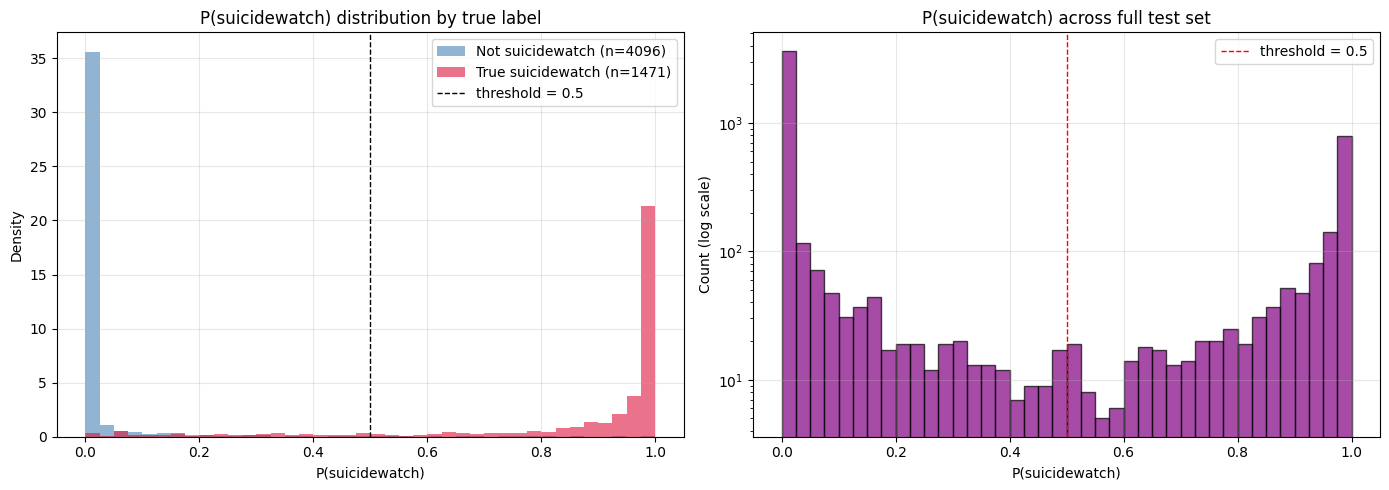


=== Stats for P(suicidewatch) ===
True suicidewatch samples (n=1471):
  mean=0.8613  median=0.9788  std=0.2433
  % above 0.5: 89.1%

Other samples (n=4096):
  mean=0.0262  median=0.0009  std=0.1051
  % above 0.5: 1.6%


In [25]:
import matplotlib.pyplot as plt

def plot_suicidal_probability_distribution(model_path, result_dict, label_col='multiclass_label',
                                            suicidal_class='suicidewatch'):
    """
    Plot the distribution of P(suicidal) across the test set,
    split by true label (suicidal vs not).
    """
    class_names = result_dict['class_names']
    num_labels = len(class_names)

    if suicidal_class not in class_names:
        raise ValueError(f"'{suicidal_class}' not in class names: {class_names}")
    suicidal_idx = class_names.index(suicidal_class)

    # Rebuild model and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Recreate the same test split used in run_experiment
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    work = work[work[label_col].isin(class_names)].reset_index(drop=True)  # <-- add this
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = work[work[label_col].isin(keep)].reset_index(drop=True)
    le = result_dict['label_encoder']
    work['_y'] = le.transform(work[label_col].astype(str))

    _, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    test_df = test_df.reset_index(drop=True)

    # Tokenize and run inference, collecting P(suicidal)
    enc = tokenizer(test_df['other_posts'].tolist(), max_length=MAX_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ds = TextClassificationDataset(enc, test_df['_y'].values)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Scoring'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_true.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.array(all_true)
    suicidal_probs = all_probs[:, suicidal_idx]

    is_suicidal = (all_true == suicidal_idx)
    probs_pos = suicidal_probs[is_suicidal]
    probs_neg = suicidal_probs[~is_suicidal]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overlaid histograms
    bins = np.linspace(0, 1, 41)
    axes[0].hist(probs_neg, bins=bins, alpha=0.6, label=f'Not {suicidal_class} (n={len(probs_neg)})',
                 color='steelblue', density=True)
    axes[0].hist(probs_pos, bins=bins, alpha=0.6, label=f'True {suicidal_class} (n={len(probs_pos)})',
                 color='crimson', density=True)
    axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[0].set_xlabel(f'P({suicidal_class})')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'P({suicidal_class}) distribution by true label')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: log-scale full test set
    axes[1].hist(suicidal_probs, bins=bins, color='purple', alpha=0.7, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(f'P({suicidal_class})')
    axes[1].set_ylabel('Count (log scale)')
    axes[1].set_title(f'P({suicidal_class}) across full test set')
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('suicidal_probability_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Stats
    print(f'\n=== Stats for P({suicidal_class}) ===')
    print(f'True {suicidal_class} samples (n={len(probs_pos)}):')
    print(f'  mean={probs_pos.mean():.4f}  median={np.median(probs_pos):.4f}  '
          f'std={probs_pos.std():.4f}')
    print(f'  % above 0.5: {(probs_pos >= 0.5).mean() * 100:.1f}%')
    print(f'\nOther samples (n={len(probs_neg)}):')
    print(f'  mean={probs_neg.mean():.4f}  median={np.median(probs_neg):.4f}  '
          f'std={probs_neg.std():.4f}')
    print(f'  % above 0.5: {(probs_neg >= 0.5).mean() * 100:.1f}%')

    return suicidal_probs, all_true


# Filter to only include classes the model was trained on
# valid_classes = result_multiclass['class_names']
# work = data[data['multiclass_label'].isin(valid_classes)].copy()

# # Filter to only include classes the model was trained on
# work_filtered = work[work['multiclass_label'].isin(valid_classes)].copy()

# Pass the filtered dataframe to the plotting function
probs, true = plot_suicidal_probability_distribution(
    model_path='best_roberta_multiclass.pt',
    result_dict=result_multiclass,
    label_col='multiclass_label',
    suicidal_class='suicidewatch',
)